In [8]:
a = "Hello World"
print(a, type(a))

Hello World <class 'str'>


In [9]:
"""
Напишите код. Задается х, напечатать какому из интервалов принадлежит: (-infinity, -5), [-5, 5] или от (5, +infinity)
"""

'\nНапишите код. Задается х, напечатать какому из интервалов принадлежит: (-infinity, -5), [-5, 5] или от (5, +infinity)\n'

In [10]:
x = -10
if x < -5:
    print("(-infinity, -5)")
elif x<=5:
    print("[-5, 5]")
else:
    print("(5, +infinity)")


(-infinity, -5)


In [11]:
x = 10
while x > 0:
    print(x)
    x -=3

10
7
4
1


In [12]:
features = [
    "age",
    "gender",
    "height",
    "weight",
    "eye_color",
    "hair_color",
    "nationality",
    "education_level",
    "profession",
    "income_level"
]

print(features)


['age', 'gender', 'height', 'weight', 'eye_color', 'hair_color', 'nationality', 'education_level', 'profession', 'income_level']


In [13]:
arr = []
for i in range(2, 16):
    arr.append(i)
print(arr)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [14]:
for i in range (106, 5, -25):
    print(i)

106
81
56
31
6


In [15]:
x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
x[::2] = x[::2][::-1]
print(x)

[8, 1, 6, 3, 4, 5, 2, 7, 0, 9]


Среднее: 0.47018074337820936
Медиана: 0.4641424546894926


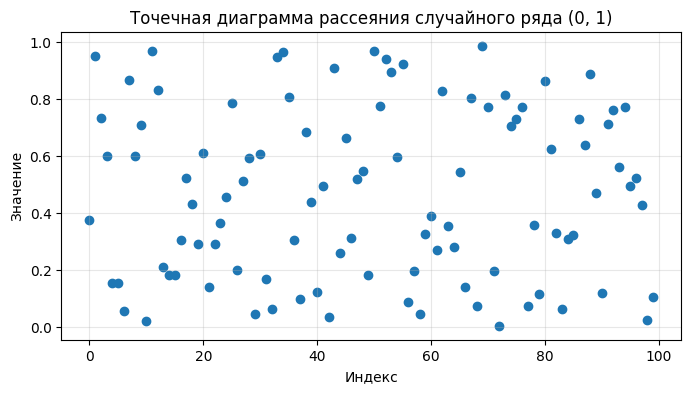

In [16]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
n = 100
x = np.random.random(n)
mean_x = np.mean(x)
median_x = np.median(x)

print("Среднее:", mean_x)
print("Медиана:", median_x)
plt.figure(figsize=(8, 4))
plt.scatter(np.arange(n), x)
plt.title("Точечная диаграмма рассеяния случайного ряда (0, 1)")
plt.xlabel("Индекс")
plt.ylabel("Значение")
plt.grid(True, alpha=0.3)
plt.show()


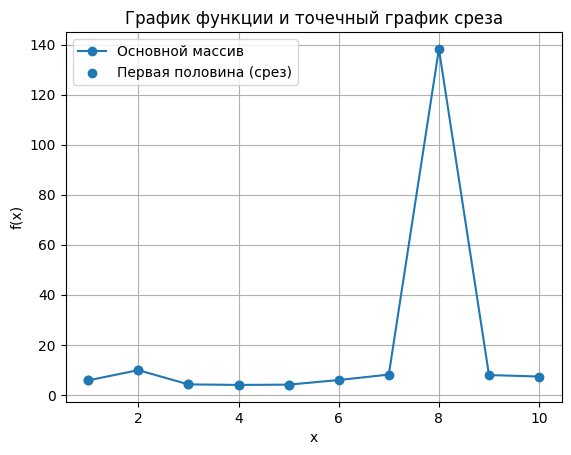

In [17]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(1, 10, 10)
y = np.sqrt(1 + np.exp(np.sqrt(x)) + np.cos(x**2)) / np.abs(1 - np.sin(x)**3) + np.log(np.abs(2*x))
x_slice = x[:len(x)//2]
y_slice = y[:len(y)//2]
plt.plot(x, y, marker='o', label='Основной массив')
plt.scatter(x_slice, y_slice, label='Первая половина (срез)')
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("График функции и точечный график среза")
plt.grid(True)
plt.show()

Первые строки:
Ticker            AAPL      GOOGL        MSFT
Date                                         
2021-01-04  125.856712  85.659294  208.406540
2021-01-05  127.412781  86.350060  208.607559
2021-01-06  123.123840  85.497993  203.198517
2021-01-07  127.325249  88.051704  208.980957
2021-01-08  128.424210  89.217400  210.254242 

Последние строки:
Ticker            AAPL       GOOGL        MSFT
Date                                          
2021-12-27  176.459732  146.797333  330.594177
2021-12-28  175.442017  145.586975  329.435822
2021-12-29  175.530121  145.555222  330.111542
2021-12-30  174.375412  145.104126  327.572601
2021-12-31  173.758957  143.765762  324.676422 

Сводная статистика:
       Доходность 2021 Годовая волатильность (≈)
Ticker                                          
GOOGL          67.83 %                   24.31 %
MSFT           55.79 %                   20.96 %
AAPL           38.06 %                   25.02 % 



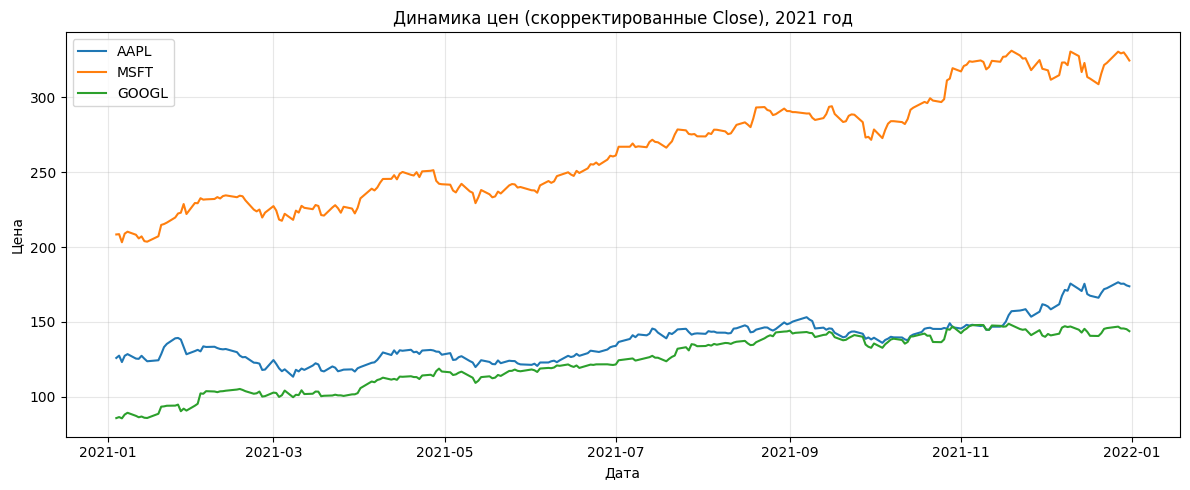

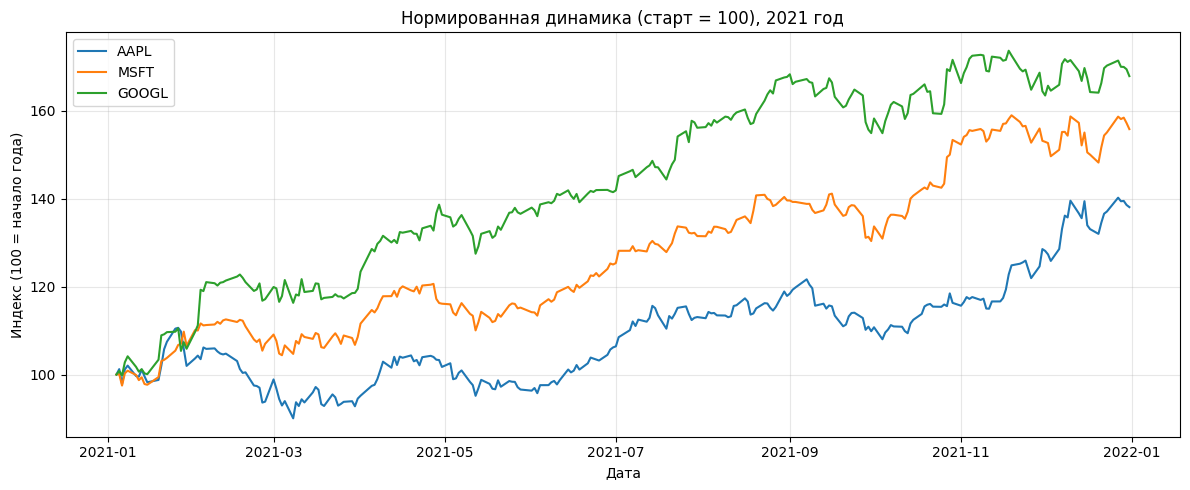

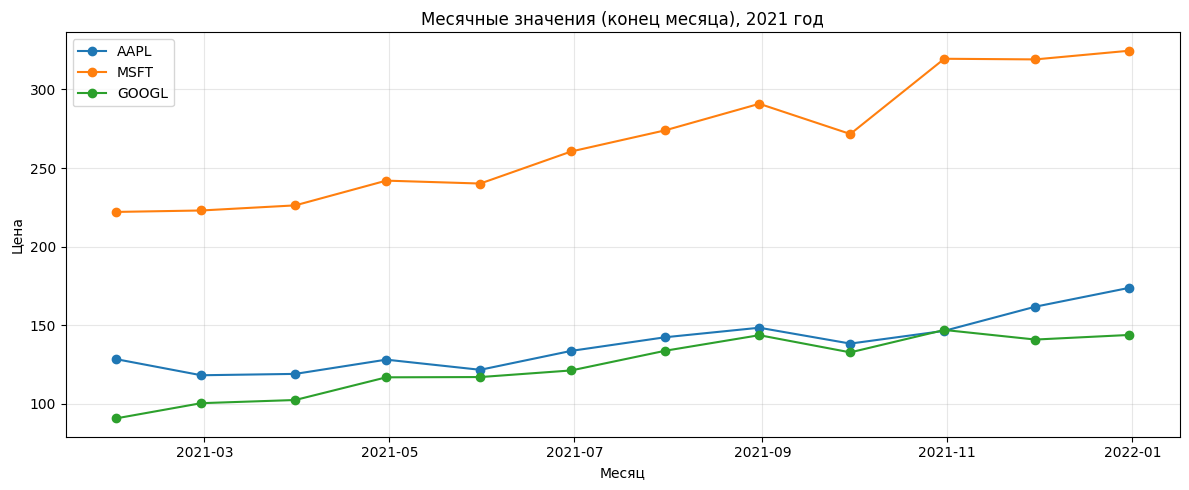

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["AAPL", "MSFT", "GOOGL"]
start, end = "2021-01-01", "2022-01-01"
data = yf.download(
    tickers,
    start=start,
    end=end,
    interval="1d",
    auto_adjust=True,
    progress=False
)
close = data["Close"].dropna(how="all")

print("Первые строки:")
print(close.head(), "\n")
print("Последние строки:")
print(close.tail(), "\n")
daily_ret = close.pct_change().dropna()

annual_return = close.iloc[-1] / close.iloc[0] - 1
annual_vol = daily_ret.std() * np.sqrt(252)

stats = pd.DataFrame({
    "Доходность 2021": annual_return,
    "Годовая волатильность (≈)": annual_vol,
}).sort_values("Доходность 2021", ascending=False)

print("Сводная статистика:")
print((stats * 100).round(2).astype(str) + " %", "\n")

plt.figure(figsize=(12, 5))
for t in tickers:
    plt.plot(close.index, close[t], label=t)

plt.title("Динамика цен (скорректированные Close), 2021 год")
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

norm = close / close.iloc[0] * 100

plt.figure(figsize=(12, 5))
for t in tickers:
    plt.plot(norm.index, norm[t], label=t)

plt.title("Нормированная динамика (старт = 100), 2021 год")
plt.xlabel("Дата")
plt.ylabel("Индекс (100 = начало года)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

monthly = close.resample("ME").last()
plt.figure(figsize=(12, 5))
for t in tickers:
    plt.plot(monthly.index, monthly[t], marker="o", label=t)

plt.title("Месячные значения (конец месяца), 2021 год")
plt.xlabel("Месяц")
plt.ylabel("Цена")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
import math

def calc(x: float, y: float, op: str) -> float:
    op = op.strip()

    if op == "+":
        return x + y
    if op == "-":
        return x - y
    if op in ("*", "·"):
        return x * y
    if op in ("/", "÷"):
        if y == 0:
            raise ZeroDivisionError("Деление на ноль")
        return x / y

    # функции
    if op.lower() in ("exp", "e", "e^(x+y)"):
        return math.exp(x + y)
    if op.lower() in ("sin", "sin(x+y)"):
        return math.sin(x + y)
    if op.lower() in ("cos", "cos(x+y)"):
        return math.cos(x + y)
    if op.lower() in ("pow", "^", "x^y"):
        return x ** y

    raise ValueError("Неизвестная операция")

def main():
    print("Калькулятор: +  -  *  /  exp  sin  cos  pow")
    while True:
        try:
            x = float(input("Введите x: ").replace(",", "."))
            y = float(input("Введите y: ").replace(",", "."))
            op = input("Операция (+, -, *, /, exp, sin, cos, pow): ")

            result = calc(x, y, op)
            print(f"Результат: {op} {result}")

        except Exception as e:
            print("Ошибка:", e)

        again = input("Ещё раз? (y/n): ").strip().lower()
        if again != "y":
            break

if __name__ == "__main__":
    main()


Калькулятор: +  -  *  /  exp  sin  cos  pow


KeyboardInterrupt: Interrupted by user